In [14]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, balanced_accuracy_score
)
import joblib 

In [15]:
data = pd.read_csv("weather_activity_dataset.csv")
data.head()

,Weather,Activity
0,Rainy,Read book
1,Rainy,Read book
2,Sunny,Picnic
3,Sunny,Picnic
4,Sunny,Picnic


In [16]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Weather   1200 non-null   object
 1   Activity  1200 non-null   object
dtypes: object(2)
memory usage: 18.9+ KB
None


In [17]:
print(data.Weather.unique())

['Rainy' 'Sunny']


In [18]:
print(data.Activity.unique())

['Read book' 'Picnic' 'Grab a drink' 'Run errands' 'Stay home'
 'Watch movie']


In [19]:
# 2) Preprocess
# One-Hot encode 'weather' ( we keep both weather_Rainy, Weather_sunny for clarity)

x = pd.get_dummies(data[['Weather']], prefix='Weather')

In [20]:
# Label Encode the muulticlass target 'Activity' 
le = LabelEncoder()
y = le.fit_transform(data['Activity'])

In [26]:
print('\n Feature Columns: ', x.columns.tolist())


 Feature Columns:  ['Weather_Rainy', 'Weather_Sunny']


In [27]:
print('Target class mapping: ')
for idx, cls in enumerate(le.classes_):
    print(f"  {idx} -> {cls}")

Target class mapping: 
  0 -> Grab a drink
  1 -> Picnic
  2 -> Read book
  3 -> Run errands
  4 -> Stay home
  5 -> Watch movie


In [28]:
# 3) Train-test split (stratified)
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size= 0.2, random_state= 42, stratify=y)

print(f"\n Train rows: {x_train.shape[0]}. Test rows: {x_test.shape[0]}")


 Train rows: 960. Test rows: 240


In [29]:
# 4) Train Decision Tree
model = DecisionTreeClassifier(criterion='entropy', random_state=42)
model.fit(x_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [30]:
# 5) Predict & evaluate 
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
balanced_acc = balanced_accuracy_score(y_test, y_pred)

In [32]:

print(f"\nTest accuracy: {accuracy:.4f}")
print(f"Balanced accuracy: {balanced_acc:.4f}\n")
print("Classification report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Test accuracy: 0.3458
Balanced accuracy: 0.3333

Classification report:

              precision    recall  f1-score   support

Grab a drink       0.35      1.00      0.52        44
      Picnic       0.00      0.00      0.00        39
   Read book       0.00      0.00      0.00        38
 Run errands       0.00      0.00      0.00        42
   Stay home       0.00      0.00      0.00        38
 Watch movie       0.34      1.00      0.51        39

    accuracy                           0.35       240
   macro avg       0.12      0.33      0.17       240
weighted avg       0.12      0.35      0.18       240



/home/agrit/Desktop/ML/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/agrit/Desktop/ML/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/agrit/Desktop/ML/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

In [33]:
# 6 confusion matrix 
cm = confusion_matrix(y_test, y_pred)
print("confusion_matrix (rows = actual, cols = predicted) : \n", cm)

confusion_matrix (rows = actual, cols = predicted) : 
 [[44  0  0  0  0  0]
 [39  0  0  0  0  0]
 [ 0  0  0  0  0 38]
 [42  0  0  0  0  0]
 [ 0  0  0  0  0 38]
 [ 0  0  0  0  0 39]]


Text(0.5, 0, 'Predicted')

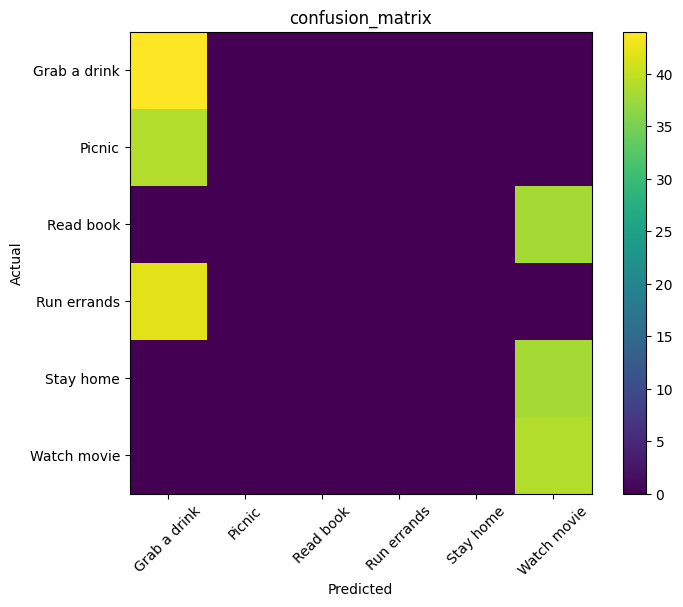

In [35]:
plt.figure(figsize= (8,6))
plt.imshow(cm, interpolation='nearest')
plt.title("confusion_matrix")
plt.colorbar()
ticks = np.arange(len(le.classes_))
plt.xticks(ticks, le.classes_, rotation=45)
plt.yticks(ticks, le.classes_)
plt.ylabel('Actual')
plt.xlabel('Predicted')

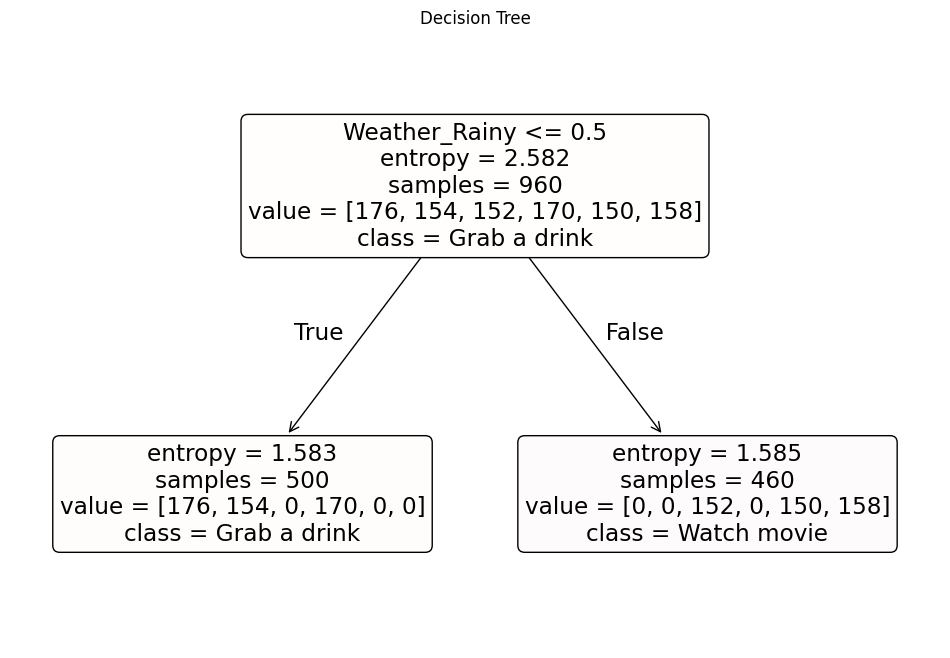

In [38]:
# 7) Decision tree visualization
plt.figure(figsize=(12,8))
plot_tree(model, feature_names=x.columns, class_names=le.classes_, filled=True, rounded=True)
plt.title("Decision Tree")
plt.show()

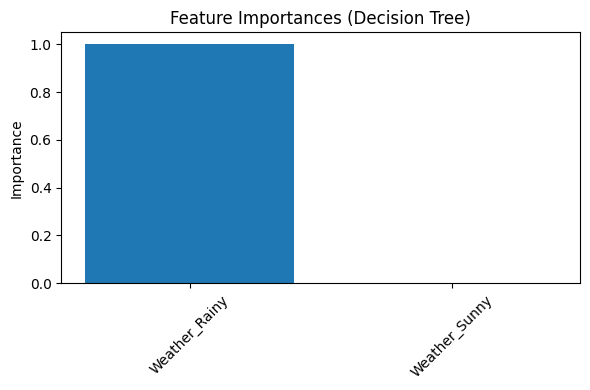

In [40]:
# 8) Feature importances
importances = model.feature_importances_
plt.figure(figsize=(6,4))
plt.bar(range(len(importances)), importances)
plt.xticks(range(len(importances)), x.columns, rotation=45)
plt.ylabel("Importance")
plt.title("Feature Importances (Decision Tree)")
plt.tight_layout()
plt.show()

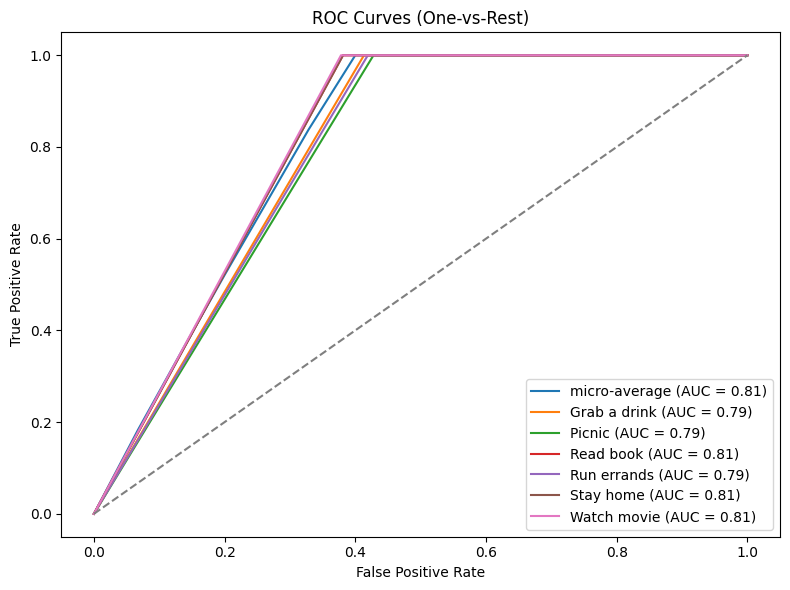

In [41]:
# 9) Multi-class ROC curves (One-vs-Rest)
n_classes = len(le.classes_)
# Binarize the true labels for ROC computation
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))
# Obtain probability estimates from the model
if hasattr(model, "predict_proba"):
    y_score = model.predict_proba(x_test)
else:
    # fallback: use decision_function (not present for DecisionTreeClassifier) or raise
    raise RuntimeError("Model does not support probability estimates needed for ROC curves.")

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# micro-average
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure(figsize=(8,6))
plt.plot(fpr["micro"], tpr["micro"], label=f"micro-average (AUC = {roc_auc['micro']:.2f})")
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"{le.classes_[i]} (AUC = {roc_auc[i]:.2f})")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest)")
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [43]:
# 10) 5-fold cross-validation accuracy
cv_scores = cross_val_score(DecisionTreeClassifier(criterion='entropy', random_state=42),
            x, y, cv=5, scoring='accuracy')
print(f"\n{5}-fold CV accuracy: mean={cv_scores.mean():.4f}, std={cv_scores.std():.4f}")


5-fold CV accuracy: mean=0.3475, std=0.0020


In [44]:
# 11) Sample predictions (show a few rows)
sample_df = x_test.copy()
sample_df['actual']  = le.inverse_transform(y_test)
sample_df['predict'] = le.inverse_transform(y_pred)
print("\nSample predictions (first 8 rows):")
print(sample_df.head(8))


Sample predictions (first 8 rows):
      Weather_Rainy  Weather_Sunny        actual       predict
603           False           True  Grab a drink  Grab a drink
302            True          False     Stay home   Watch movie
897           False           True  Grab a drink  Grab a drink
571           False           True  Grab a drink  Grab a drink
1125          False           True        Picnic  Grab a drink
0              True          False     Read book   Watch movie
379           False           True  Grab a drink  Grab a drink
833            True          False   Watch movie   Watch movie


In [45]:
# 12) Save the trained model (optional)
model_path = os.path.join('.', "decision_tree_model.joblib")
joblib.dump({'model': model, 'label_encoder': le}, model_path)
print(f"\nSaved trained model + label encoder to: {model_path}")

print("\nPipeline complete. Output files are in: current directory")


Saved trained model + label encoder to: ./decision_tree_model.joblib

Pipeline complete. Output files are in: current directory
